<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit5/EmilChafU5proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

# Linear Regression
For this project, I will be modeling the decrease in fuel efficiency based on the increase in engine size. I will model this for a variety of different car brands, varying from luxury companies like Lamborghini and Porsche to more affordable options like GMC and Toyota. Fuel efficiency is important because it can provide important information that influences factors such as mileage and gas costs, helping for affordability and price.

I found this dataset on Kaggle, and I believe that it will yield fairly accurate results due to the large size.

In [2]:
url_car = 'https://raw.githubusercontent.com/emilchafigoulline/Data-Science/refs/heads/main/Unit5/co2.csv'
car_data= pd.read_csv(url_car)
car_data

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


In [3]:
print(car_data.columns)
car_data["Make"] = car_data["Make"].astype("category")

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


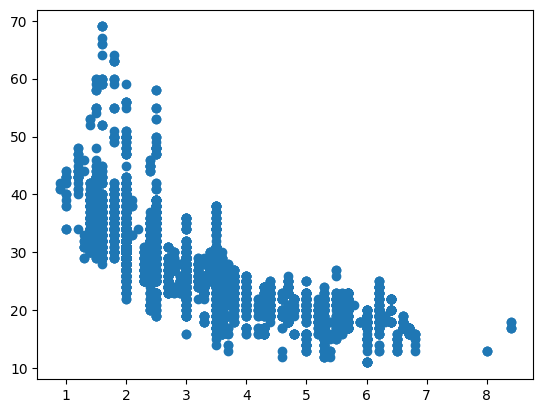

In [4]:
plt.scatter(car_data['Engine Size(L)'], car_data['Fuel Consumption Comb (mpg)'])

While this data doesn't quite appear linear, it is close enough to use for our purposes. There appears to be a negative correlation between engine size and fuel efficiency, so as the engine gets larger the engine gets less efficient.

In [5]:
make_idx = car_data.Make.cat.codes.values

make_codes = car_data.Make.cat.categories

car_coords = {"make":make_codes}
# takes each value in Make and creates categories

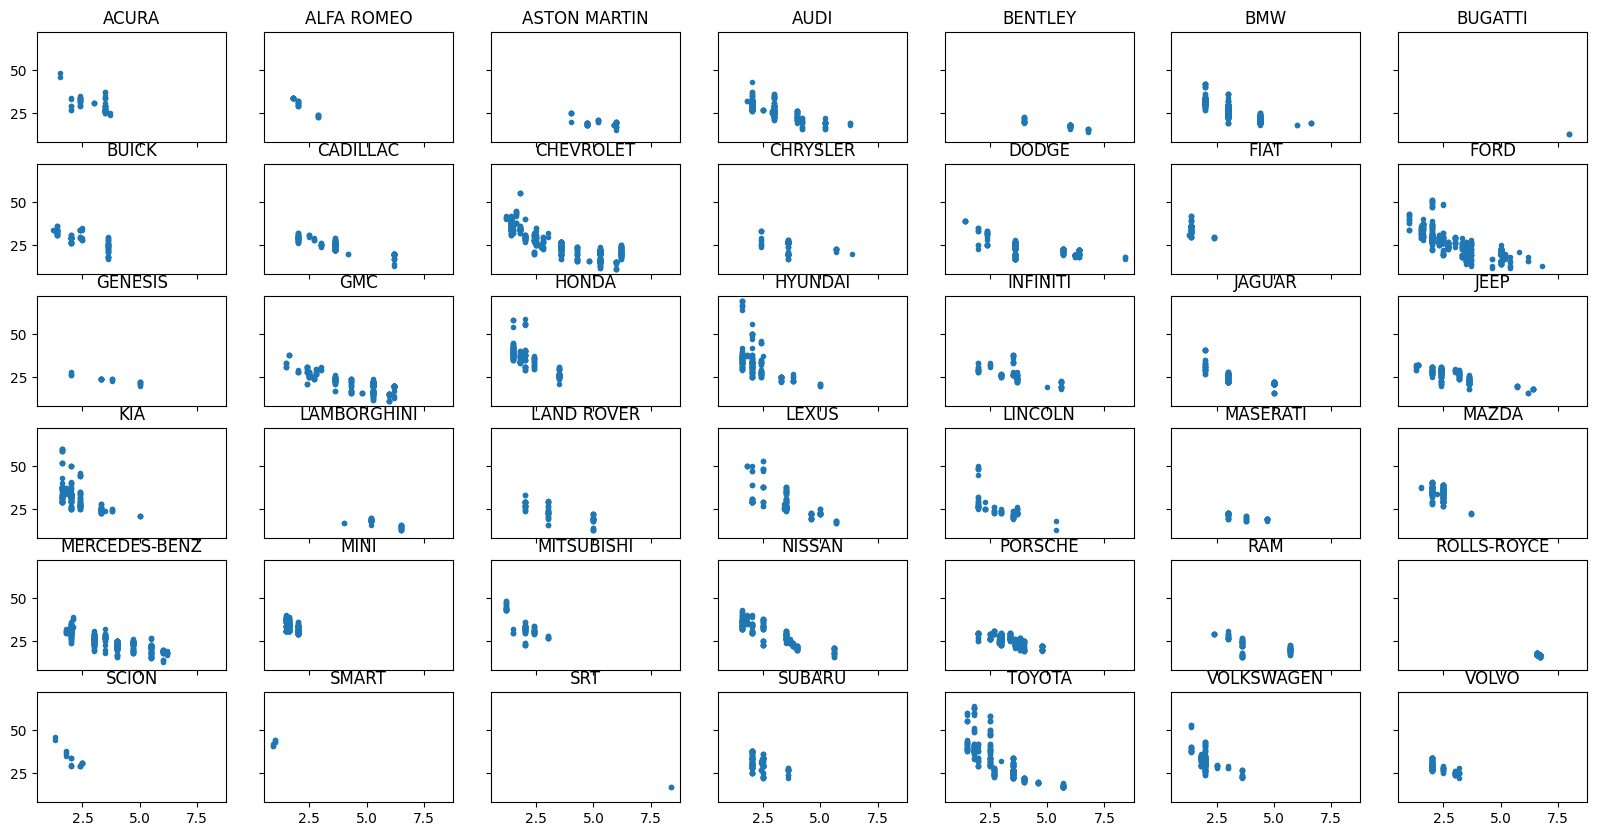

In [6]:
_, ax = plt.subplots(6, 7, figsize=(20, 10), sharex=True, sharey=True)
ax = np.ravel(ax)

for i, p in enumerate(make_codes):
    ax[i].scatter(
        x = car_data.query('Make == @p')['Engine Size(L)'],
        y =  car_data.query('Make == @p')['Fuel Consumption Comb (mpg)'],
        marker=".")
    ax[i].set_title(f"{p}")
    #creates a subplot for each make

As we can see from these subplots, there is almost always a negative correlation between increasing engine size and fuel consumption, seen in the vast majority of the data. We will now draw the line of best fit and 94% HDI for each subcategory.

In [ ]:
with pm.Model(coords={"Make":make_codes}) as nh_model:
    # Priors
    α = pm.Normal("α", mu=25, sigma=10, dims="Make") #intercept for each engine
    β = pm.Normal("β", mu=0, sigma=10, dims="Make") # roc for each engine
    σ = pm.HalfNormal("σ", 1)                          # standard deviation

    # Linear setup
    mu = α[make_idx] + β[make_idx] * car_data['Engine Size(L)']

    # Likelihood
    y = pm.Normal("y", mu=mu, sigma=σ, observed=car_data['Fuel Consumption Comb (mpg)'])

    # Sampling
    idata_nh = pm.sample(init="jitter+adapt_diag", tune=2000, return_inferencedata=True)


/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/

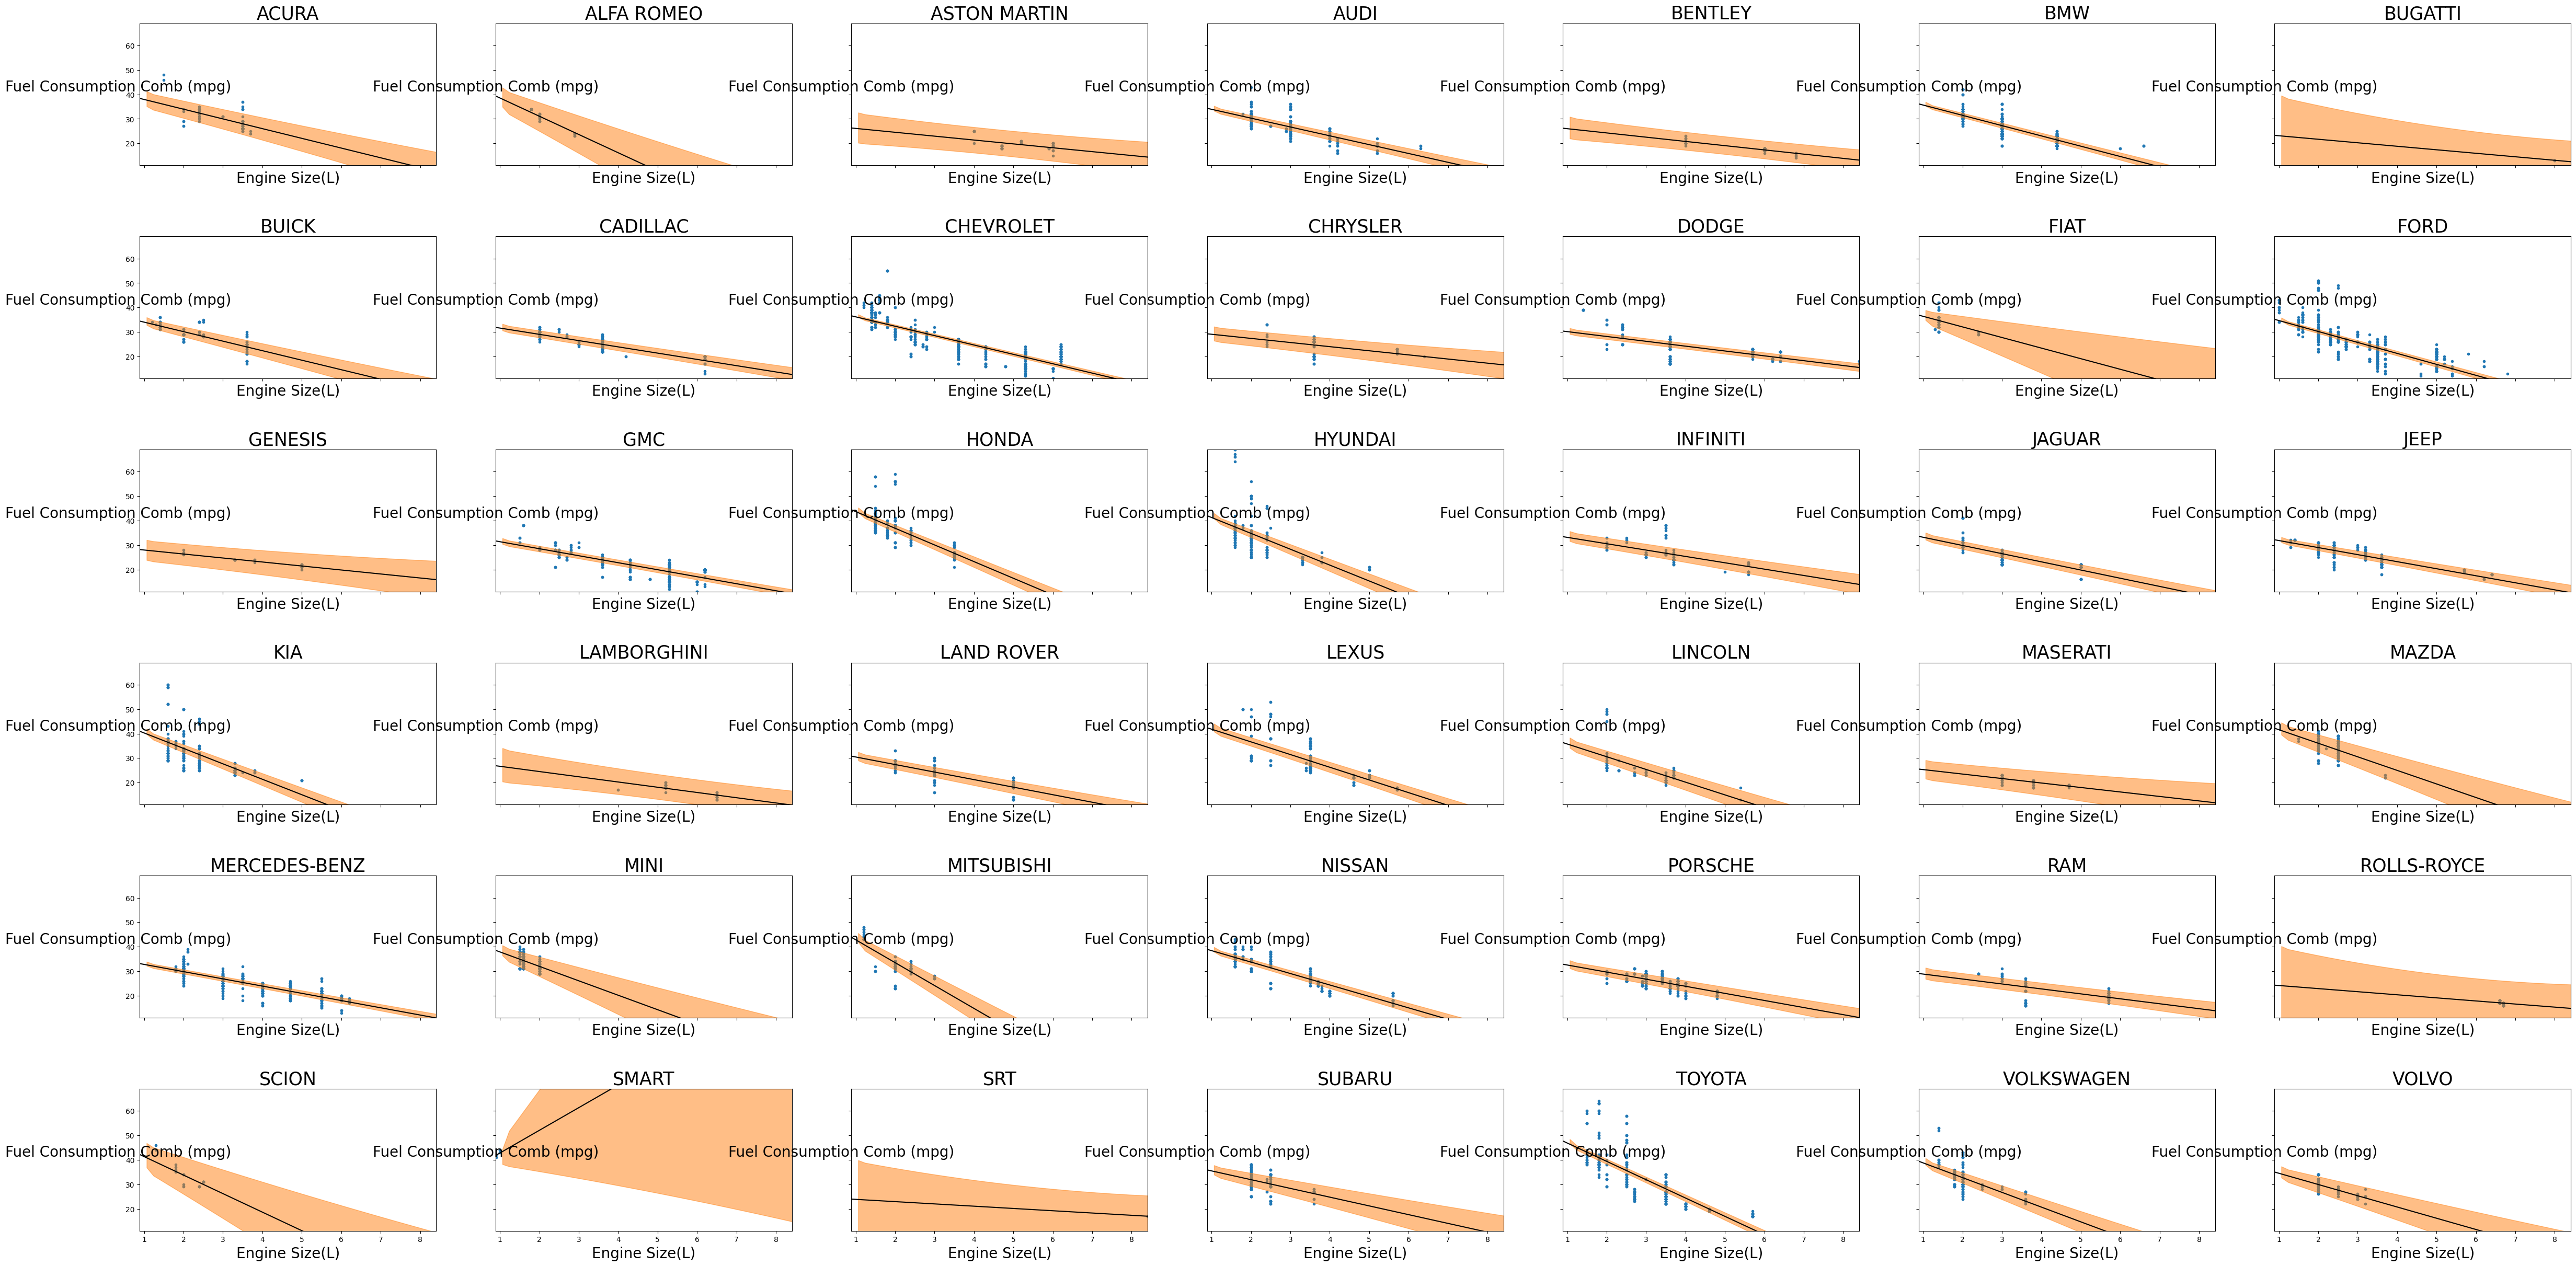

In [8]:

# Sets up 42 plots for all makes(oops this is a lot of subplots so it's hard to read)
_, ax = plt.subplots(6, 7, figsize=(60, 30), sharex=True, sharey=True)
plt.subplots_adjust(hspace = 0.5, wspace = 0.2)
plt.yticks(rotation = 90)
ax = np.ravel(ax)

# Set up x values
x_range = np.linspace(car_data['Engine Size(L)'].min(), car_data['Fuel Consumption Comb (mpg)'].max(), 10)

# Grab posterior info
posterior = az.extract(idata_nh)

# For each position
for i, p in enumerate(make_codes):
    ax[i].scatter(
        x = car_data.query('Make == @p')['Engine Size(L)'],
        y = car_data.query('Make == @p')['Fuel Consumption Comb (mpg)'],
        marker=".")

    # titles and labels
    ax[i].set_title(f"{p}", fontsize = 25)
    ax[i].set_xlabel("Engine Size(L)", fontsize = 20)
    ax[i].set_ylabel("Fuel Consumption Comb (mpg)", fontsize = 20, labelpad=10, rotation=0)

    alphas = posterior["α"].sel(Make=p)
    betas = posterior["β"].sel(Make=p)
    alpha_m = alphas.mean("sample").item()
    beta_m = betas.mean("sample").item()

    # LOBF
    ax[i].plot(x_range, alpha_m + beta_m * x_range, c="k")

    # Plot a 94% HDI LOBF
    az.plot_hdi(x_range, alphas + betas * xr.DataArray(x_range).transpose(), ax=ax[i])

    # graph limits
    plt.xlim(car_data['Engine Size(L)'].min() - 0.01, car_data['Engine Size(L)'].max() + 0.01)
    plt.ylim(car_data['Fuel Consumption Comb (mpg)'].min() - 0.01, car_data['Fuel Consumption Comb (mpg)'].max() + 0.01)

And here we have it. We can see that every line with sufficient data has negative slope, indicating that increasing engine size leads to decreasing efficiency. This is likely because larger engines have more friction internally, increasing the energy lost and leading to less fuel producing energy.

In [ ]:
pm.sample_posterior_predictive(idata_nh, model=nh_model,  extend_inferencedata=True)

<Axes: xlabel='y'>

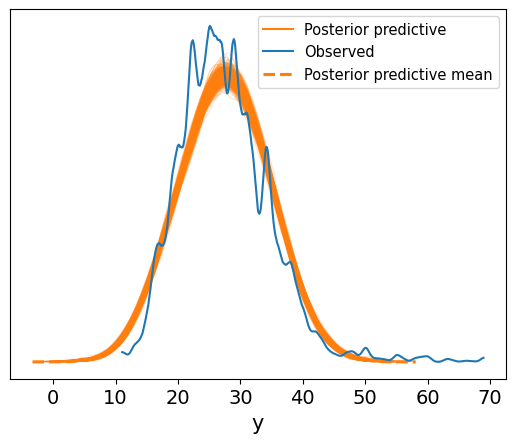

In [10]:
az.plot_ppc(idata_nh, num_pp_samples=500, colors=["C1", "C0", "C1"])

Here is our posterior predictive, which is fairly accurate to the changing data, but doesn't quite capture the height or skew of the data.

Now we will make a linear model using the entire dataset, rather than seperating it into subplots.

In [ ]:
with pm.Model() as model_whole:
    α = pm.Normal("α", mu=25, sigma=10)
    β = pm.Normal("β", mu=0, sigma=10)

    μ = pm.Deterministic("μ", α + β * car_data["Engine Size(L)"])
    σ = pm.HalfCauchy("σ", 10)

    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=car_data['Fuel Consumption Comb (mpg)'])

    idata_whole = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_whole, model=model_whole,  extend_inferencedata=True)

Text(0, 0.5, 'Fuel Consumption Comb (mpg)')

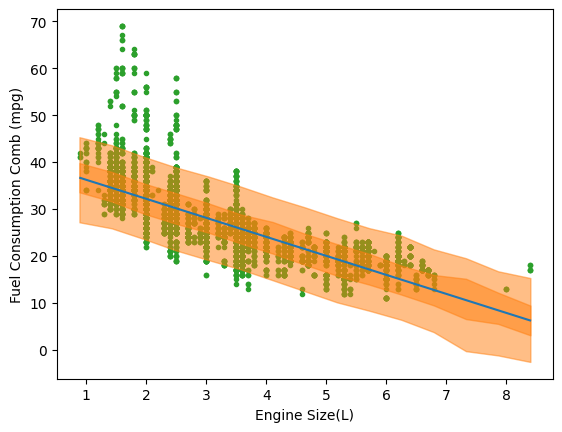

In [13]:
#grabs the expected line
mean_line = idata_whole.posterior["μ"].mean(("chain", "draw"))

models = np.random.normal(car_data["Engine Size(L)"].values, 0.01)
idx = np.argsort(models)
x = np.linspace(models.min(), models.max(), 15)

#94% HDI and 50% HDI
y_pred_q = idata_whole.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        PchipInterpolator(models[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

#plots raw data and LOBF
_, ax = plt.subplots()
ax.plot(car_data["Engine Size(L)"], car_data["Fuel Consumption Comb (mpg)"], "C2.", zorder=-3)
ax.plot(car_data["Engine Size(L)"][idx], mean_line[idx], c="C0")


#94% and 50% HDI
for whole, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, whole, ub, color="C1", alpha=0.5)

ax.set_xlabel("Engine Size(L)")
ax.set_ylabel("Fuel Consumption Comb (mpg)")


This shows how there is a general negative line correlated to the data, and how the majority of the data fits within the line. While there is some higher data, indicating that there are more efficient engines at certain sizes, the majority of the data fits into this 94% HDI line.

<Axes: xlabel='y_pred'>

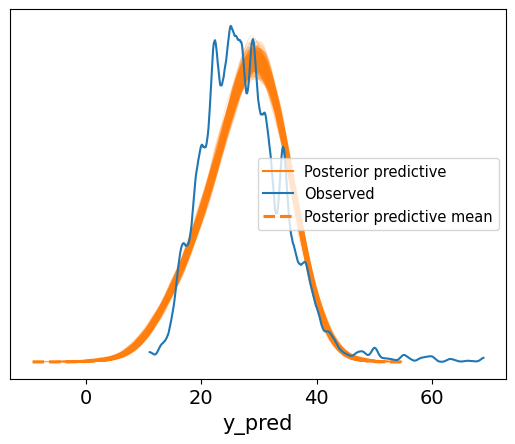

In [15]:
az.plot_ppc(idata_whole, num_pp_samples=500, colors=["C1", "C0", "C1"])

For this dataset, our model needs to be shifted to the left, as the observed is consistently less than our posterior predictive would expect.